## Metodo di bisezione

1. **INPUT**: intervallo iniziale $[a,b]=[a_1,b_1]$; una function per calcolare la funzione oggetto della ricerca; il parametro di tolleranza
2. Si ricava il numero di iterazioni sufficienti a soddisfare la tolleranza
3. Per ogni iterazione $k$:
4. Si calcola il punto medio $c_k$ dell'intervallo di ricerca $[a_k,b_k]$
5. Si definisce il nuovo intervallo di ricerca $[a_{k+1},b_{k+1}]$ come quello tra i due sottointervalli $[a_k,c_k]$, $[c_k,b_k]$ in cui sono soddisfatte le ipotesi del teorema del valor medio:

$$
\left[a_{k+1},b_{k+1}\right] = \left\{
\begin{array}{ll}
\left[a_k,c_k\right] &  \text{ se } f(c_k)\cdot f(a_k) < 0 \\
\left[c_k,b_k\right] & \text{ se } f(c_k)\cdot f(b_k) < 0
\end{array}\right.
$$


In [29]:
import numpy as np

def bisezione(f,a,b,tol):

    # Calcolo degli estremi dell'intervallo
    fa = f(a)
    fb = f(b)
    
    # Verifica condizioni iniziali (Teorema del Valor Medio)
    if fa*fb > 0:
        print("condizioni iniziali non verificate")
        return 0
    
    # Calcolo preventivo del numero di iterazioni necessarie
    N = int(np.log2((b-a)/tol)) + 1
    
    for k in range(N):
        
        # Calcolo del punto medio
        c  = a + (b-a)/2
        fc = f(c)
        
        print(f"{k})\tfc = {fc}\tc = {c}")
        
        # Scelta del sotto intervallo (che verifichi il TVM)
        if fa*fc < 0:
            b  = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return c

**Esperimento numerico**
Applichiamo il metodo di bisezione alla ricerca di uno zero della funzione seguente
$$f(x) = \sin(x) - \left(\frac x 2\right)^2$$
nell'intervallo $[1,2]$

In [30]:
def f_esempio(x):
  return np.sin(x) - (x/2)**2

a = 1
b = 2

Verifichiamo graficamente che nell'intervallo $[1,2]$ esista almeno una rafice della funzione $f$

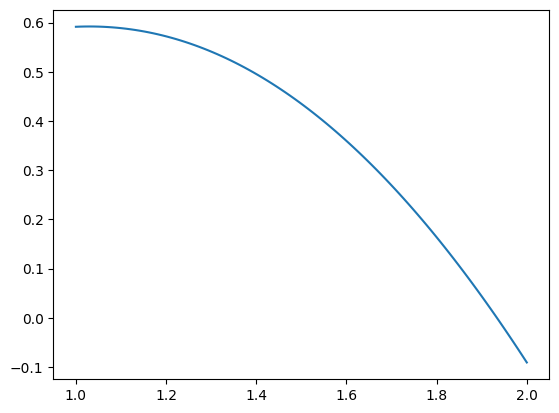

In [31]:
import matplotlib.pyplot as plt

x = np.linspace(a,b,num=100)
y = f_esempio(x)
plt.plot(x,y)
plt.show()

In [32]:
sol_bisezione = bisezione(f_esempio,a,b,1e-4)

0)	fc = 0.43499498660405445	c = 1.5
1)	fc = 0.21836094687393692	c = 1.75
2)	fc = 0.07517953160969382	c = 1.875
3)	fc = -0.0049622816376238	c = 1.9375
4)	fc = 0.035813793060754495	c = 1.90625
5)	fc = 0.015601412838988415	c = 1.921875
6)	fc = 0.005363397451792373	c = 1.9296875
7)	fc = 0.00021150537499570188	c = 1.93359375
8)	fc = -0.0023726525881073712	c = 1.935546875
9)	fc = -0.0010798895547514675	c = 1.9345703125
10)	fc = -0.00043402105622292186	c = 1.93408203125
11)	fc = -0.00011121507961475707	c = 1.933837890625
12)	fc = 5.0155838263177266e-05	c = 1.9337158203125
13)	fc = -3.0526948073039684e-05	c = 1.93377685546875


## Metodo di Newton
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)} $$

In [33]:
#def newton(f,df,x0,tol,Nmax):



In [34]:
def df_esempio(x):
  return np.cos(x)-x/2

x0 = 1.5
tol = 1e-4
sol_newton= newton(f_esempio,df_esempio,x0,tol,15)

NameError: name 'newton' is not defined

#Funzioni di libreria in SciPy

Metodi per le equazioni nonlineari sono implementati in `scipy.optimize`

`root_scalar` per le equazioni di una sola variabile  [documentazione](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html#scipy.optimize.root_scalar)

`fsolve` può risolvere anche sistemi di equazioni nonlineari in più variabili [documentazione](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fsolve.html)

In [ ]:
from scipy.optimize import root_scalar

sol_root = root_scalar(f_esempio,bracket=[a,b],method="bisect",rtol=tol)
print(sol_root.root,sol_root.iterations,sol_root.function_calls)

sol_root = root_scalar(f_esempio,x0=x0,fprime=df_esempio,method="newton",rtol=tol)
print(sol_root.root,sol_root.iterations,sol_root.function_calls)


In [ ]:
from scipy.optimize import fsolve
sol_fsolve = fsolve(f_esempio,x0,xtol=tol,fprime=df_esempio,full_output=True)
#root, info, ier, msg = fsolve(..., full_output=True)
print(sol_fsolve[0])
print(sol_fsolve[1]["nfev"],sol_fsolve[1]["njev"])


#Esercizi suggeriti
Implementare il metodo di regula falsi e il metodo delle secanti ed aggiungerli al confronto numerico.